## 1. Import Libraries

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import requests
from time import sleep
import os
import glob
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import cdist
import pytz
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Libraries imported!")

✅ Libraries imported!


## 2. Configuration

In [2]:
# File paths
XML_FILE_PATH = r"C:\Project\Apple Health Data\data\apple_health_export\export_cleaned.xml"
GPX_FOLDER = r"C:\Project\Apple Health Data\data\apple_health_export\workout-routes"
OUTPUT_DIR = r"C:\Project\Apple Health Data\output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Heart Rate types
HR_TYPES = [
    "HKQuantityTypeIdentifierHeartRate",
    "HKQuantityTypeIdentifierRestingHeartRate",
    "HKQuantityTypeIdentifierWalkingHeartRateAverage"
]

print(f"📁 XML File: {XML_FILE_PATH}")
print(f"📁 GPX Folder: {GPX_FOLDER}")
print(f"📁 Output: {OUTPUT_DIR}")

📁 XML File: C:\Project\Apple Health Data\data\apple_health_export\export_cleaned.xml
📁 GPX Folder: C:\Project\Apple Health Data\data\apple_health_export\workout-routes
📁 Output: C:\Project\Apple Health Data\output


## 3. Extract Heart Rate Data

In [3]:
def extract_heart_rate_data(xml_path):
    """Extract HR data with streaming parser for memory efficiency."""
    records = []
    record_count = 0
    
    print("⏳ Extracting Heart Rate data...")
    print("=" * 60)
    
    for event, elem in ET.iterparse(xml_path, events=('end',)):
        if elem.tag == 'Record':
            record_count += 1
            record_type = elem.get('type', '')
            
            if record_type in HR_TYPES:
                records.append({
                    'type': record_type.replace('HKQuantityTypeIdentifier', ''),
                    'sourceName': elem.get('sourceName', ''),
                    'value': float(elem.get('value', 0)),
                    'unit': elem.get('unit', ''),
                    'startDate': elem.get('startDate', ''),
                    'endDate': elem.get('endDate', ''),
                })
            
            elem.clear()
            
            if record_count % 500000 == 0:
                print(f"  Scanned {record_count:,} records... Found {len(records):,} HR records")
    
    print("=" * 60)
    print(f"✅ Extracted {len(records):,} Heart Rate records")
    
    df = pd.DataFrame(records)
    
    if len(df) > 0:
        df['startDate'] = pd.to_datetime(
            df['startDate'].str.replace(r' [+-]\d{4}$', '', regex=True)
        )
        df['endDate'] = pd.to_datetime(
            df['endDate'].str.replace(r' [+-]\d{4}$', '', regex=True)
        )
        df = df.sort_values('startDate').reset_index(drop=True)
    
    return df

hr_df = extract_heart_rate_data(XML_FILE_PATH)

⏳ Extracting Heart Rate data...
  Scanned 500,000 records... Found 356,862 HR records
  Scanned 1,000,000 records... Found 356,862 HR records
  Scanned 1,500,000 records... Found 356,862 HR records
  Scanned 2,000,000 records... Found 356,862 HR records
  Scanned 2,500,000 records... Found 356,862 HR records
✅ Extracted 360,282 Heart Rate records


## 3.5. Data Cleaning - Heart Rate

In [4]:
def clean_heart_rate_data(df):
    """Clean heart rate data based on analysis insights.
    
    Cleaning steps:
    1. Remove physiologically unrealistic HR values (<40 or >200 bpm)
    2. Remove duplicate records (same timestamp and value)
    3. Flag statistical outliers using IQR method per HR type
    """
    print("⏳ Cleaning Heart Rate data...")
    print("=" * 60)
    
    initial_count = len(df)
    print(f"Initial HR records: {initial_count:,}")
    
    # 1. Remove HR outliers (physiologically unrealistic values)
    hr_outliers = df[(df['value'] < 40) | (df['value'] > 200)]
    if len(hr_outliers) > 0:
        print(f"  ⚠ Removed {len(hr_outliers):,} HR outliers (<40 or >200 bpm)")
    df = df[(df['value'] >= 40) & (df['value'] <= 200)].copy()
    
    # 2. Remove duplicates (same timestamp and value)
    duplicates = df.duplicated(subset=['startDate', 'value'], keep='first')
    dup_count = duplicates.sum()
    if dup_count > 0:
        print(f"  ⚠ Removed {dup_count:,} duplicate HR records")
    df = df[~duplicates].copy()
    
    # 3. Statistical outlier detection using IQR method (per HR type)
    outlier_mask = pd.Series([False] * len(df), index=df.index)
    
    for hr_type in df['type'].unique():
        type_mask = df['type'] == hr_type
        values = df.loc[type_mask, 'value']
        
        Q1 = values.quantile(0.25)
        Q3 = values.quantile(0.75)
        IQR = Q3 - Q1
        
        # Use 3*IQR for lenient outlier detection
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        statistical_outliers = (values < lower_bound) | (values > upper_bound)
        outlier_mask[type_mask] = statistical_outliers
        
        if statistical_outliers.sum() > 0:
            print(f"  ⚠ {hr_type}: Flagged {statistical_outliers.sum():,} statistical outliers")
    
    # Store outlier flag for analysis
    df['statistical_outlier'] = outlier_mask
    
    # 4. Summary
    final_count = len(df)
    removed_count = initial_count - final_count
    
    print("=" * 60)
    print(f"✅ HR Data Cleaning Complete:")
    print(f"   Retained: {final_count:,} records ({final_count/initial_count*100:.2f}%)")
    print(f"   Removed: {removed_count:,} records ({removed_count/initial_count*100:.2f}%)")
    print(f"   Statistical outliers flagged: {outlier_mask.sum():,}")
    print()
    
    return df

# Apply cleaning
hr_df = clean_heart_rate_data(hr_df)

⏳ Cleaning Heart Rate data...
Initial HR records: 360,282
  ⚠ Removed 104 duplicate HR records
  ⚠ HeartRate: Flagged 240 statistical outliers
  ⚠ WalkingHeartRateAverage: Flagged 2 statistical outliers
  ⚠ RestingHeartRate: Flagged 9 statistical outliers
✅ HR Data Cleaning Complete:
   Retained: 360,178 records (99.97%)
   Removed: 104 records (0.03%)
   Statistical outliers flagged: 251



## 4. Extract Workout Data

In [5]:
def extract_workout_data(xml_path):
    """Extract workout sessions with metadata."""
    workouts = []
    
    print("⏳ Extracting Workout data...")
    
    for event, elem in ET.iterparse(xml_path, events=('end',)):
        if elem.tag == 'Workout':
            workout = {
                'workoutType': elem.get('workoutActivityType', '').replace('HKWorkoutActivityType', ''),
                'duration': float(elem.get('duration', 0)),
                'durationUnit': elem.get('durationUnit', ''),
                'totalDistance': float(elem.get('totalDistance', 0) or 0),
                'totalDistanceUnit': elem.get('totalDistanceUnit', ''),
                'totalEnergyBurned': float(elem.get('totalEnergyBurned', 0) or 0),
                'sourceName': elem.get('sourceName', ''),
                'startDate': elem.get('startDate', ''),
                'endDate': elem.get('endDate', ''),
            }
            workouts.append(workout)
            elem.clear()
    
    print(f"✅ Extracted {len(workouts):,} Workout records")
    
    df = pd.DataFrame(workouts)
    
    if len(df) > 0:
        df['startDate'] = pd.to_datetime(
            df['startDate'].str.replace(r' [+-]\d{4}$', '', regex=True)
        )
        df['endDate'] = pd.to_datetime(
            df['endDate'].str.replace(r' [+-]\d{4}$', '', regex=True)
        )
        df = df.sort_values('startDate').reset_index(drop=True)
    
    return df

workouts_df = extract_workout_data(XML_FILE_PATH)

⏳ Extracting Workout data...
✅ Extracted 289 Workout records


## 4.5. Data Cleaning - Workouts

In [6]:
def clean_workout_data(df):
    """Clean workout data based on analysis insights.
    
    Cleaning steps:
    1. Remove workouts with unrealistic short duration (<5 minutes)
    2. Fix distance data for distance-based activities
    3. Remove duplicate workout sessions
    4. Flag suspicious workout records
    """
    print("⏳ Cleaning Workout data...")
    print("=" * 60)
    
    initial_count = len(df)
    print(f"Initial workout records: {initial_count:,}")
    
    if len(df) == 0:
        print("  ⚠ No workout data to clean")
        return df
    
    # 1. Remove workouts with unrealistic duration
    # Convert duration to minutes (if in seconds)
    if 'durationUnit' in df.columns and df['durationUnit'].iloc[0] == 'min':
        df['duration_minutes'] = df['duration']
    else:
        df['duration_minutes'] = df['duration'] / 60  # assume seconds
    
    short_workouts = df[df['duration_minutes'] < 5]
    if len(short_workouts) > 0:
        print(f"  ⚠ Removed {len(short_workouts):,} workouts with duration <5 minutes")
    df = df[df['duration_minutes'] >= 5].copy()
    
    # 2. Fix distance data for distance-based activities
    distance_activities = ['Running', 'Cycling', 'Hiking', 'Walking']
    
    for activity in distance_activities:
        activity_mask = df['workoutType'] == activity
        zero_distance = activity_mask & (df['totalDistance'] == 0)
        
        if zero_distance.sum() > 0:
            print(f"  ⚠ {activity}: {zero_distance.sum():,} workouts with zero distance flagged")
            # Flag instead of remove (might be indoor workouts)
            df.loc[zero_distance, 'suspicious_distance'] = True
    
    # Initialize suspicious_distance column for non-flagged rows
    if 'suspicious_distance' not in df.columns:
        df['suspicious_distance'] = False
    df['suspicious_distance'] = df['suspicious_distance'].fillna(False)
    
    # 3. Remove duplicate workouts (same type, start time)
    duplicates = df.duplicated(subset=['workoutType', 'startDate'], keep='first')
    dup_count = duplicates.sum()
    if dup_count > 0:
        print(f"  ⚠ Removed {dup_count:,} duplicate workout records")
    df = df[~duplicates].copy()
    
    # 4. Flag workouts with unusual energy/distance ratios
    for activity in distance_activities:
        activity_mask = df['workoutType'] == activity
        activity_data = df[activity_mask]
        
        if len(activity_data) > 0 and activity_data['totalDistance'].sum() > 0:
            # Calculate energy per km
            valid_mask = (activity_data['totalDistance'] > 0) & (activity_data['totalEnergyBurned'] > 0)
            if valid_mask.sum() > 5:  # need at least 5 samples
                energy_per_km = activity_data.loc[valid_mask, 'totalEnergyBurned'] / activity_data.loc[valid_mask, 'totalDistance']
                
                Q1 = energy_per_km.quantile(0.25)
                Q3 = energy_per_km.quantile(0.75)
                IQR = Q3 - Q1
                
                lower_bound = Q1 - 3 * IQR
                upper_bound = Q3 + 3 * IQR
                
                unusual = (energy_per_km < lower_bound) | (energy_per_km > upper_bound)
                if unusual.sum() > 0:
                    print(f"  ⚠ {activity}: {unusual.sum():,} workouts with unusual energy/distance ratio")
    
    # 5. Summary
    final_count = len(df)
    removed_count = initial_count - final_count
    
    print("=" * 60)
    print(f"✅ Workout Data Cleaning Complete:")
    print(f"   Retained: {final_count:,} records ({final_count/initial_count*100:.2f}%)")
    print(f"   Removed: {removed_count:,} records ({removed_count/initial_count*100:.2f}%)")
    print(f"   Suspicious distance flagged: {df['suspicious_distance'].sum():,}")
    print()
    
    # Workout type distribution after cleaning
    if len(df) > 0:
        print("📊 Workout distribution after cleaning:")
        workout_counts = df['workoutType'].value_counts()
        for workout_type, count in workout_counts.items():
            print(f"   {workout_type:15s}: {count:3,} workouts")
        print()
    
    return df

# Apply cleaning
workouts_df = clean_workout_data(workouts_df)

⏳ Cleaning Workout data...
Initial workout records: 289
  ⚠ Removed 11 workouts with duration <5 minutes
  ⚠ Running: 1 workouts with zero distance flagged
  ⚠ Cycling: 10 workouts with zero distance flagged
  ⚠ Hiking: 1 workouts with zero distance flagged
  ⚠ Walking: 176 workouts with zero distance flagged
✅ Workout Data Cleaning Complete:
   Retained: 278 records (96.19%)
   Removed: 11 records (3.81%)
   Suspicious distance flagged: 188

📊 Workout distribution after cleaning:
   Walking        : 176 workouts
   Rowing         :  90 workouts
   Cycling        :  10 workouts
   Hiking         :   1 workouts
   Running        :   1 workouts



## 5. Data Overview

In [7]:
print("📊 DATA SUMMARY")
print("=" * 50)
print(f"\n🫀 Heart Rate Data:")
print(f"   Total records: {len(hr_df):,}")
print(f"   Date range: {hr_df['startDate'].min()} → {hr_df['startDate'].max()}")
print(f"   Types: {hr_df['type'].unique().tolist()}")

print(f"\n🏃 Workout Data:")
print(f"   Total workouts: {len(workouts_df):,}")
print(f"   Date range: {workouts_df['startDate'].min()} → {workouts_df['startDate'].max()}")
print(f"   Unique workout types: {workouts_df['workoutType'].nunique()}")

print(f"\n📋 Top Workout Types:")
print(workouts_df['workoutType'].value_counts())

📊 DATA SUMMARY

🫀 Heart Rate Data:
   Total records: 360,178
   Date range: 2017-11-27 09:47:34 → 2022-09-23 10:59:44
   Types: ['HeartRate', 'WalkingHeartRateAverage', 'RestingHeartRate']

🏃 Workout Data:
   Total workouts: 278
   Date range: 2018-01-07 13:09:46 → 2022-09-22 10:11:43
   Unique workout types: 5

📋 Top Workout Types:
workoutType
Walking    176
Rowing      90
Cycling     10
Hiking       1
Running      1
Name: count, dtype: int64


## 6. Phase 1: Context Enrichment

Transform raw time-series data into context-aware events by adding temporal, activity, and physiological contexts.

In [8]:
# Phase 1.A: Add Temporal Contexts
print("⏳ Adding temporal contexts...")

# Extract hour, day_of_week, is_weekend
hr_df['hour'] = hr_df['startDate'].dt.hour
hr_df['day_of_week'] = hr_df['startDate'].dt.dayofweek  # Monday=0, Sunday=6
hr_df['is_weekend'] = hr_df['day_of_week'].isin([5, 6])  # Saturday=5, Sunday=6

# Create time_period column
def get_time_period(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 22:
        return 'evening'
    else:  # 22-6
        return 'night'

hr_df['time_period'] = hr_df['hour'].apply(get_time_period)

print(f"✅ Temporal contexts added: time_period, hour, day_of_week, is_weekend")
print(f"   Time periods distribution:\n{hr_df['time_period'].value_counts()}")

⏳ Adding temporal contexts...
✅ Temporal contexts added: time_period, hour, day_of_week, is_weekend
   Time periods distribution:
time_period
afternoon    135094
morning       92043
evening       88802
night         44239
Name: count, dtype: int64


In [9]:
# Phase 1.B: Add Activity Contexts
print("⏳ Adding activity contexts (matching with workouts)...")

# Initialize columns
hr_df['in_workout'] = False
hr_df['activity_context'] = 'resting'
hr_df['workout_type'] = None

# Match each HR record with workouts based on timestamp overlap
matched_count = 0
for idx, workout in tqdm(workouts_df.iterrows(), total=len(workouts_df), desc="Matching workouts"):
    # Find HR records that fall within this workout's time window
    mask = (hr_df['startDate'] >= workout['startDate']) & (hr_df['startDate'] <= workout['endDate'])
    
    # Update the matched records
    hr_df.loc[mask, 'in_workout'] = True
    hr_df.loc[mask, 'activity_context'] = workout['workoutType']
    hr_df.loc[mask, 'workout_type'] = workout['workoutType']
    
    matched_count += mask.sum()

print(f"✅ Activity contexts added: in_workout, activity_context, workout_type")
print(f"   HR records during workouts: {hr_df['in_workout'].sum():,} ({hr_df['in_workout'].sum()/len(hr_df)*100:.2f}%)")
print(f"   Activity context distribution:\n{hr_df['activity_context'].value_counts()}")

⏳ Adding activity contexts (matching with workouts)...


Matching workouts: 100%|████████████████████████████████████████████████████████████| 278/278 [00:01<00:00, 222.60it/s]

✅ Activity contexts added: in_workout, activity_context, workout_type
   HR records during workouts: 8,020 (2.23%)
   Activity context distribution:
activity_context
resting    352158
Walking      5792
Rowing       1710
Cycling       500
Hiking         17
Running         1
Name: count, dtype: int64


In [10]:
# Phase 1.C: Add Physiological Contexts
print("⏳ Adding physiological contexts...")

# Define user age and calculate max HR
USER_AGE = 40  # Can edit later
MAX_HR = 208 - (0.7 * USER_AGE )

print(f"   User age: {USER_AGE}")
print(f"   Calculated Max HR: {MAX_HR} bpm")

# Calculate HR percentage
hr_df['hr_percentage'] = (hr_df['value'] / MAX_HR) * 100

# Create hr_zone based on % of max HR
def get_hr_zone(hr_pct):
    if hr_pct < 30:
        return 'very_low'
    elif hr_pct < 40:
        return 'low'
    elif hr_pct < 50:
        return 'moderate'
    elif hr_pct < 80:
        return 'high'
    else:
        return 'very_high'

hr_df['hr_zone'] = hr_df['hr_percentage'].apply(get_hr_zone)

print(f"✅ Physiological contexts added: hr_zone, hr_percentage")
print(f"   HR zones distribution:\n{hr_df['hr_zone'].value_counts()}")
print(f"   HR percentage - Mean: {hr_df['hr_percentage'].mean():.2f}%, Std: {hr_df['hr_percentage'].std():.2f}%")

⏳ Adding physiological contexts...
   User age: 40
   Calculated Max HR: 180.0 bpm
✅ Physiological contexts added: hr_zone, hr_percentage
   HR zones distribution:
hr_zone
very_low     221574
low          116686
moderate      20222
high           1533
very_high       163
Name: count, dtype: int64
   HR percentage - Mean: 48.66%, Std: 6.62%


In [11]:
# Phase 1 Checkpoint: Verify all columns added
print("=" * 60)
print("✅ PHASE 1 CHECKPOINT: Context Enrichment Complete")
print("=" * 60)

# Expected new columns
expected_columns = [
    'time_period', 'hour', 'day_of_week', 'is_weekend',  # Temporal (4)
    'activity_context', 'in_workout', 'workout_type',     # Activity (3)
    'hr_zone', 'hr_percentage'                             # Physiological (2)
]

print(f"\n📋 New Columns Added ({len(expected_columns)}):")
for col in expected_columns:
    if col in hr_df.columns:
        null_count = hr_df[col].isnull().sum()
        dtype = hr_df[col].dtype
        print(f"   ✓ {col:20s} | Type: {str(dtype):10s} | Nulls: {null_count:,}")
    else:
        print(f"   ✗ {col:20s} | MISSING!")

print(f"\n📊 Enriched DataFrame Shape: {hr_df.shape}")
print(f"   Total columns: {len(hr_df.columns)}")
print(f"   Total rows: {len(hr_df):,}")

print(f"\n🔍 Sample of enriched data:")
print(hr_df[['startDate', 'value', 'time_period', 'hour', 'activity_context', 
             'in_workout', 'hr_zone', 'hr_percentage']].head(10))

✅ PHASE 1 CHECKPOINT: Context Enrichment Complete

📋 New Columns Added (9):
   ✓ time_period          | Type: object     | Nulls: 0
   ✓ hour                 | Type: int32      | Nulls: 0
   ✓ day_of_week          | Type: int32      | Nulls: 0
   ✓ is_weekend           | Type: bool       | Nulls: 0
   ✓ activity_context     | Type: object     | Nulls: 0
   ✓ in_workout           | Type: bool       | Nulls: 0
   ✓ workout_type         | Type: object     | Nulls: 352,158
   ✓ hr_zone              | Type: object     | Nulls: 0
   ✓ hr_percentage        | Type: float64    | Nulls: 0

📊 Enriched DataFrame Shape: (360178, 16)
   Total columns: 16
   Total rows: 360,178

🔍 Sample of enriched data:
            startDate  value time_period  hour activity_context  in_workout  \
0 2017-11-27 09:47:34   82.0     morning     9          resting       False   
1 2017-11-27 10:00:39   72.0     morning    10          resting       False   
2 2017-11-27 10:01:51   74.0     morning    10          resting

## 7. Phase 2: COPE Knowledge Graph Construction

Build a NetworkX directed graph where nodes represent physiological events and contexts, and edges represent relationships between them.

In [12]:
# Import NetworkX for graph construction
import networkx as nx

print("✅ NetworkX imported for graph construction")

✅ NetworkX imported for graph construction


In [13]:
# Phase 2.1: Create empty NetworkX DiGraph and add event nodes
print("⏳ Creating COPE Knowledge Graph...")
print("=" * 60)

# Step 1: Create empty directed graph
G = nx.DiGraph()
print("✅ Step 1: Created empty NetworkX DiGraph")

# Step 2: Add event nodes (one per HR record)
print("⏳ Step 2: Adding physiological_event nodes...")

event_nodes_added = 0
for idx, row in tqdm(hr_df.iterrows(), total=len(hr_df), desc="Adding event nodes"):
    node_id = f"event_{idx}"
    
    # Add node with properties
    G.add_node(
        node_id,
        node_type='physiological_event',
        hr_value=row['value'],
        hr_type=row['type'],
        timestamp=row['startDate'],
        hr_zone=row['hr_zone'],
        in_workout=row['in_workout'],
        hr_percentage=row['hr_percentage'],
        time_period=row['time_period'],
        hour=row['hour'],
        day_of_week=row['day_of_week'],
        activity_context=row['activity_context']
    )
    event_nodes_added += 1

print(f"✅ Step 2: Added {event_nodes_added:,} physiological_event nodes")
print(f"   Current graph size: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

⏳ Creating COPE Knowledge Graph...
✅ Step 1: Created empty NetworkX DiGraph
⏳ Step 2: Adding physiological_event nodes...


Adding event nodes: 100%|███████████████████████████████████████████████████| 360178/360178 [00:17<00:00, 20120.12it/s]


✅ Step 2: Added 360,178 physiological_event nodes
   Current graph size: 360,178 nodes, 0 edges


In [14]:
# Phase 2.2: Add context nodes (unique combinations only)
print("⏳ Step 3: Adding context nodes...")

# 3A: Add temporal_context nodes
temporal_contexts = hr_df[['time_period', 'day_of_week', 'is_weekend']].drop_duplicates()
temporal_nodes_added = 0

for _, row in temporal_contexts.iterrows():
    node_id = f"temporal_{row['time_period']}_{row['day_of_week']}"
    G.add_node(
        node_id,
        node_type='temporal_context',
        time_period=row['time_period'],
        day_of_week=row['day_of_week'],
        is_weekend=row['is_weekend']
    )
    temporal_nodes_added += 1

print(f"   ✓ Added {temporal_nodes_added} temporal_context nodes")

# 3B: Add activity_context nodes
activity_types = hr_df['activity_context'].unique()
activity_nodes_added = 0

for activity_type in activity_types:
    node_id = f"activity_{activity_type}"
    G.add_node(
        node_id,
        node_type='activity_context',
        activity_type=activity_type
    )
    activity_nodes_added += 1

print(f"   ✓ Added {activity_nodes_added} activity_context nodes")

# 3C: Add physiological_context nodes (HR zones)
hr_zones = hr_df['hr_zone'].unique()
physio_nodes_added = 0

for zone in hr_zones:
    node_id = f"physio_{zone}"
    G.add_node(
        node_id,
        node_type='physiological_context',
        intensity_zone=zone
    )
    physio_nodes_added += 1

print(f"   ✓ Added {physio_nodes_added} physiological_context nodes")

total_context_nodes = temporal_nodes_added + activity_nodes_added + physio_nodes_added
print(f"✅ Step 3: Added {total_context_nodes} context nodes in total")
print(f"   Current graph size: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

⏳ Step 3: Adding context nodes...
   ✓ Added 28 temporal_context nodes
   ✓ Added 6 activity_context nodes
   ✓ Added 5 physiological_context nodes
✅ Step 3: Added 39 context nodes in total
   Current graph size: 360,217 nodes, 0 edges


In [15]:
# Phase 2.3: Add contextual edges (event → context)
print("⏳ Step 4: Adding contextual edges...")

contextual_edges_added = 0

for idx, row in tqdm(hr_df.iterrows(), total=len(hr_df), desc="Adding contextual edges"):
    event_id = f"event_{idx}"
    
    # Edge 1: occurs_in_time (event → temporal_context)
    temporal_id = f"temporal_{row['time_period']}_{row['day_of_week']}"
    G.add_edge(event_id, temporal_id, relation='occurs_in_time')
    contextual_edges_added += 1
    
    # Edge 2: occurs_during (event → activity_context)
    activity_id = f"activity_{row['activity_context']}"
    G.add_edge(event_id, activity_id, relation='occurs_during')
    contextual_edges_added += 1
    
    # Edge 3: exhibits (event → physiological_context)
    physio_id = f"physio_{row['hr_zone']}"
    G.add_edge(event_id, physio_id, relation='exhibits')
    contextual_edges_added += 1

print(f"✅ Step 4: Added {contextual_edges_added:,} contextual edges")
print(f"   Current graph size: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

⏳ Step 4: Adding contextual edges...


Adding contextual edges: 100%|██████████████████████████████████████████████| 360178/360178 [00:14<00:00, 25708.16it/s]


✅ Step 4: Added 1,080,534 contextual edges
   Current graph size: 360,217 nodes, 1,080,534 edges


In [16]:
# Phase 2.4: Add temporal sequence edges (event → next_event)
print("⏳ Step 5: Adding temporal sequence edges (precedes)...")

TIME_GAP_THRESHOLD = 3600  # 1 hour in seconds

sequence_edges_added = 0

# Iterate through consecutive events
for i in tqdm(range(len(hr_df) - 1), desc="Adding sequence edges"):
    current_event_id = f"event_{i}"
    next_event_id = f"event_{i+1}"
    
    # Calculate time gap between events
    current_time = hr_df.iloc[i]['startDate']
    next_time = hr_df.iloc[i+1]['startDate']
    time_gap = (next_time - current_time).total_seconds()
    
    # Only add edge if time gap < 1 hour
    if time_gap < TIME_GAP_THRESHOLD:
        G.add_edge(
            current_event_id, 
            next_event_id, 
            relation='precedes',
            time_gap=time_gap
        )
        sequence_edges_added += 1

print(f"✅ Step 5: Added {sequence_edges_added:,} temporal sequence edges")
print(f"   (Only connected events with time gap < {TIME_GAP_THRESHOLD} seconds)")
print(f"   Current graph size: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

⏳ Step 5: Adding temporal sequence edges (precedes)...


Adding sequence edges: 100%|████████████████████████████████████████████████| 360177/360177 [00:33<00:00, 10617.98it/s]


✅ Step 5: Added 358,414 temporal sequence edges
   (Only connected events with time gap < 3600 seconds)
   Current graph size: 360,320 nodes, 1,438,948 edges


In [17]:
# Phase 2.5: Save graph and verify
print("⏳ Step 6: Saving graph to file...")

# Save graph using pickle
import pickle

graph_file_path = os.path.join(OUTPUT_DIR, 'cope_graph.gpickle')

with open(graph_file_path, 'wb') as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)

# Get file size
file_size_mb = os.path.getsize(graph_file_path) / (1024 * 1024)

print(f"✅ Step 6: Graph saved to {graph_file_path}")
print(f"   File size: {file_size_mb:.2f} MB")

⏳ Step 6: Saving graph to file...
✅ Step 6: Graph saved to C:\Project\Apple Health Data\output\cope_graph.gpickle
   File size: 110.54 MB


In [18]:
# Phase 2 Checkpoint: Verify graph structure
print("=" * 60)
print("✅ PHASE 2 CHECKPOINT: COPE Graph Construction Complete")
print("=" * 60)

# Graph statistics
total_nodes = G.number_of_nodes()
total_edges = G.number_of_edges()

# Count nodes by type
node_types = {}
for node, data in G.nodes(data=True):
    node_type = data.get('node_type', 'unknown')
    node_types[node_type] = node_types.get(node_type, 0) + 1

# Count edges by relation
edge_relations = {}
for u, v, data in G.edges(data=True):
    relation = data.get('relation', 'unknown')
    edge_relations[relation] = edge_relations.get(relation, 0) + 1

# Display statistics
print(f"\n📊 Graph Statistics:")
print(f"   Total nodes: {total_nodes:,}")
print(f"   Total edges: {total_edges:,}")

print(f"\n📋 Node Types:")
for node_type, count in sorted(node_types.items()):
    print(f"   {node_type:25s}: {count:,}")

print(f"\n🔗 Edge Types:")
for relation, count in sorted(edge_relations.items()):
    print(f"   {relation:25s}: {count:,}")

# Validation checks
print(f"\n✓ Validation:")
expected_event_nodes = len(hr_df)
actual_event_nodes = node_types.get('physiological_event', 0)

if actual_event_nodes == expected_event_nodes:
    print(f"   ✓ Event nodes: {actual_event_nodes:,} (matches HR records)")
else:
    print(f"   ✗ Event nodes mismatch: expected {expected_event_nodes:,}, got {actual_event_nodes:,}")

context_nodes_total = (node_types.get('temporal_context', 0) + 
                       node_types.get('activity_context', 0) + 
                       node_types.get('physiological_context', 0))

if 40 <= context_nodes_total <= 100:
    print(f"   ✓ Context nodes: {context_nodes_total} (within expected range 40-100)")
else:
    print(f"   ⚠ Context nodes: {context_nodes_total} (expected range: 40-100)")

expected_contextual = actual_event_nodes * 3
actual_contextual = (edge_relations.get('occurs_in_time', 0) + 
                     edge_relations.get('occurs_during', 0) + 
                     edge_relations.get('exhibits', 0))

if actual_contextual == expected_contextual:
    print(f"   ✓ Contextual edges: {actual_contextual:,} (3 per event)")
else:
    print(f"   ⚠ Contextual edges: {actual_contextual:,} (expected {expected_contextual:,})")

sequence_edges = edge_relations.get('precedes', 0)
if 200000 <= sequence_edges <= 400000:
    print(f"   ✓ Sequence edges: {sequence_edges:,} (within expected range)")
else:
    print(f"   ⚠ Sequence edges: {sequence_edges:,} (expected range: 200K-400K)")

# Check if file exists and get size
if os.path.exists(graph_file_path):
    file_size_mb = os.path.getsize(graph_file_path) / (1024 * 1024)
    print(f"\n💾 Graph saved to: {graph_file_path}")
    print(f"   File size: {file_size_mb:.2f} MB")
else:
    print(f"\n⚠ Graph file not found at: {graph_file_path}")

print("\n" + "=" * 60)

✅ PHASE 2 CHECKPOINT: COPE Graph Construction Complete

📊 Graph Statistics:
   Total nodes: 360,320
   Total edges: 1,438,948

📋 Node Types:
   activity_context         : 6
   physiological_context    : 5
   physiological_event      : 360,178
   temporal_context         : 28
   unknown                  : 103

🔗 Edge Types:
   exhibits                 : 360,178
   occurs_during            : 360,178
   occurs_in_time           : 360,178
   precedes                 : 358,414

✓ Validation:
   ✓ Event nodes: 360,178 (matches HR records)
   ⚠ Context nodes: 39 (expected range: 40-100)
   ✓ Contextual edges: 1,080,534 (3 per event)
   ✓ Sequence edges: 358,414 (within expected range)

💾 Graph saved to: C:\Project\Apple Health Data\output\cope_graph.gpickle
   File size: 110.54 MB



## 8. Phase 3: GNN Model Implementation

Convert COPE graph to PyTorch Geometric format and implement a Graph Neural Network for anomaly detection.

In [19]:
# Import required libraries for GNN
print("⏳ Importing PyTorch and PyTorch Geometric libraries...")

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, GATConv
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import joblib # To save the configuration
    import warnings

    # Turn off unnecessary pandas alerts.
    warnings.filterwarnings('ignore')

    # Set up the device.
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 Running on Device: {device}")

    
    print(f"✅ Libraries imported successfully!")
    print(f"   PyTorch version: {torch.__version__}")
    print(f"   CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   CUDA device: {torch.cuda.get_device_name(0)}")
    
except ImportError as e:
    print(f"❌ Error importing libraries: {e}")

⏳ Importing PyTorch and PyTorch Geometric libraries...
🚀 Running on Device: cpu
✅ Libraries imported successfully!
   PyTorch version: 2.5.1+cpu
   CUDA available: False


In [20]:
# 1. DATA PREPARATION (Contextual Merging)
# ==========================================
print("\n[1/7] ⏳ Merging Data & Creating Context...")

# Ensure data is sorted by timestamp
hr_df = hr_df.sort_values('startDate')
workouts_df = workouts_df.sort_values('startDate')

# Merge: Find the most recent workout for each heart rate data point
merged_df = pd.merge_asof(
    hr_df,
    workouts_df[['startDate', 'endDate', 'workoutType']],
    left_on='startDate',
    right_on='startDate',
    direction='backward'
)

# Context Assignment Logic: If HR occurs during a workout, assign the workout type; otherwise, label as 'Resting'
def assign_context(row):
    if pd.notnull(row['endDate_y']) and row['startDate'] <= row['endDate_y']:
        return row['workoutType']
    return 'Resting/Daily'

merged_df['context'] = merged_df.apply(assign_context, axis=1)

# Encode Context & Normalize Heart Rate (HR)
le = LabelEncoder()
merged_df['context_id'] = le.fit_transform(merged_df['context'])

scaler = StandardScaler()
merged_df['hr_norm'] = scaler.fit_transform(merged_df[['value']])


[1/7] ⏳ Merging Data & Creating Context...


In [21]:
# ==========================================
# 2. FEATURE ENGINEERING (CPRA Logic)
# ==========================================
print("[2/7] ⏳ Calculating Statistical Probabilities (CPRA)...")

# Step 1: Binning (Group heart rate levels)
bins = [0, 60, 100, 140, 220]
labels_bin = ['Low', 'Normal', 'High', 'Extreme']
merged_df['hr_bin'] = pd.cut(merged_df['value'], bins=bins, labels=labels_bin)

# Step 2: Calculate conditional probability P(HR_Bin | Context)
prob_matrix = merged_df.groupby(['context', 'hr_bin'], observed=False).size() / merged_df.groupby('context', observed=False).size()
prob_df = prob_matrix.reset_index(name='path_prob')

# Step 3: Merge back to dataframe
merged_df = pd.merge(merged_df, prob_df, on=['context', 'hr_bin'], how='left')
merged_df['path_prob'] = merged_df['path_prob'].fillna(1e-6)

# Step 4: Generate pseudo-labels based on rarest 6% of data (can change)
anomaly_threshold = merged_df['path_prob'].quantile(0.06)
merged_df['label'] = (merged_df['path_prob'] < anomaly_threshold).astype(int)

print(f"   -> Anomaly Probability Threshold: < {anomaly_threshold:.4f}")
print(f"   -> Total Anomalies Generated: {merged_df['label'].sum()} ({merged_df['label'].mean()*100:.2f}%)")

[2/7] ⏳ Calculating Statistical Probabilities (CPRA)...
   -> Anomaly Probability Threshold: < 0.1277
   -> Total Anomalies Generated: 2492 (0.69%)


In [22]:
# ==========================================
# 3. GRAPH CONSTRUCTION
# ==========================================
print("[3/7] ⏳ Constructing Graph Data...")

# Node Features: [HR Norm, Context ID, Path Probability]
x = torch.tensor(merged_df[['hr_norm', 'context_id', 'path_prob']].values, dtype=torch.float)

# Edges: Connecting time series (t -> t+1)
num_nodes = len(merged_df)
source = torch.arange(0, num_nodes - 1, dtype=torch.long)
target = torch.arange(1, num_nodes, dtype=torch.long)
edge_index = torch.stack([source, target], dim=0)

# Labels
y = torch.tensor(merged_df['label'].values, dtype=torch.long)

# Time-based Split (70% Train, 15% Val, 15% Test)
train_split = int(num_nodes * 0.70)
val_split = int(num_nodes * 0.85)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:train_split] = True
val_mask[train_split:val_split] = True
test_mask[val_split:] = True

# PyG Data Object
data = Data(x=x, edge_index=edge_index, y=y).to(device)

[3/7] ⏳ Constructing Graph Data...


In [23]:
# ==========================================
# 4. GNN MODEL DEFINITION
# ==========================================
class HealthGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(HealthGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        out = self.classifier(x)
        return out

model = HealthGNN(input_dim=3, hidden_dim=64, output_dim=2).to(device)

In [24]:
# ==========================================
# 5. TRAINING (With Class Weights)
# ==========================================
print("[4/7] ⏳ Training GNN...")

# Calculate Class Weights automatically.
labels_train = data.y[train_mask]
n_neg = (labels_train == 0).sum().item()
n_pos = (labels_train == 1).sum().item()
pos_weight = min(n_neg / (n_pos + 1e-5), 10.0) # Cap weight max = 10

class_weights = torch.tensor([1.0, pos_weight], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

epochs = 60 # Optimal number of epochs from previous experiments
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 20 == 0:
        print(f"   Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

[4/7] ⏳ Training GNN...
   Epoch 20/60 | Loss: 0.1328
   Epoch 40/60 | Loss: 0.0791
   Epoch 60/60 | Loss: 0.0717


In [25]:
# ==========================================
# 6. THRESHOLD OPTIMIZATION
# ==========================================
print("\n[5/7] ⏳ Optimizing Decision Threshold...")

model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = F.softmax(out, dim=1)[:, 1] # Find the probability of the Anomaly class.
    
    # Assessment based on the test set.
    y_test = data.y[test_mask].cpu().numpy()
    probs_test = probs[test_mask].cpu().numpy()

# Find the best F1 threshold.
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_test)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"   ✅ Best Threshold Found: {best_threshold:.4f}")
print(f"   ✅ Max F1-Score: {best_f1:.4f}")



[5/7] ⏳ Optimizing Decision Threshold...
   ✅ Best Threshold Found: 0.6105
   ✅ Max F1-Score: 0.6754



[6/7] 📊 Final Evaluation (Test Set)...
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     53818
     Anomaly       0.62      0.74      0.67       209

    accuracy                           1.00     54027
   macro avg       0.81      0.87      0.84     54027
weighted avg       1.00      1.00      1.00     54027


[7/7] 💾 Saving System...
   ✅ Model & Config saved successfully!


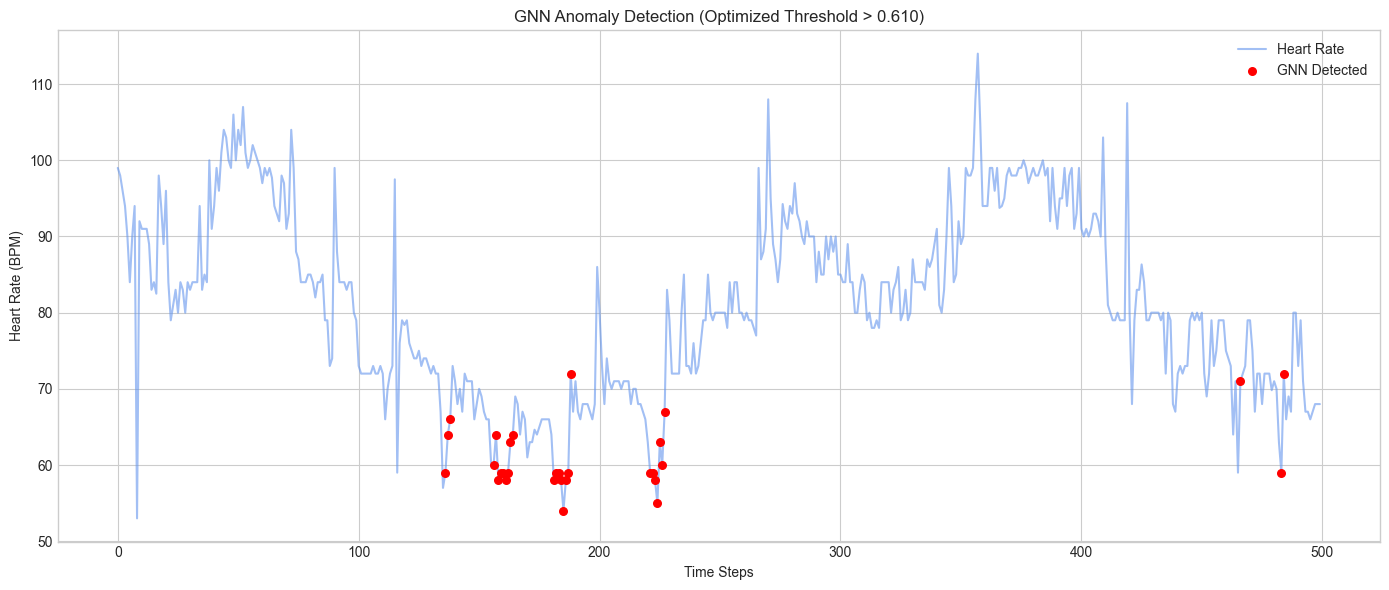

In [26]:
# ==========================================
# 7. FINAL EVALUATION & SAVING
# ==========================================
print("\n[6/7] 📊 Final Evaluation (Test Set)...")

# Áp dụng ngưỡng tối ưu
preds_test = (probs_test > best_threshold).astype(int)
print(classification_report(y_test, preds_test, target_names=['Normal', 'Anomaly'], zero_division=0))

# Lưu Model & Config
print("\n[7/7] 💾 Saving System...")
torch.save(model.state_dict(), 'health_gnn_optimized.pth')
system_config = {
    'threshold': best_threshold,
    'scaler': scaler,
    'label_encoder': le,
    'input_dim': 3,
    'hidden_dim': 64
}
joblib.dump(system_config, 'gnn_config_optimized.pkl')
print("   ✅ Model & Config saved successfully!")

# Vẽ biểu đồ kết quả
plt.figure(figsize=(14, 6))
plot_start = val_split + 1000
plot_len = 500
indices = range(plot_start, plot_start + plot_len)

hr_vals = merged_df['value'].iloc[indices].values
plt.plot(range(plot_len), hr_vals, label='Heart Rate', color='cornflowerblue', alpha=0.6)

# Tô màu dự đoán (Predicted Anomalies)
test_probs_subset = probs[indices].cpu().numpy()
pred_anoms = [i for i, p in enumerate(test_probs_subset) if p > best_threshold]
if pred_anoms:
    plt.scatter(pred_anoms, hr_vals[pred_anoms], color='red', label='GNN Detected', s=30, zorder=5)

plt.title(f"GNN Anomaly Detection (Optimized Threshold > {best_threshold:.3f})")
plt.xlabel("Time Steps")
plt.ylabel("Heart Rate (BPM)")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
import torch.nn.functional as F

# ==========================================
# 7. INSPECT DETECTED ANOMALIES (ANALYSIS)
# ==========================================
print("⏳ Extracting details of detected anomalies...")

# --- STEP 1: GET PREDICTIONS ---
# Recalculate probabilities for entire dataset to ensure index alignment
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    all_probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()

# Extract only TEST data (from val_split onwards)
# This is data the model has never seen during training -> Most objective
analysis_df = merged_df.iloc[val_split:].copy()
analysis_df['anomaly_prob'] = all_probs[val_split:]

# --- STEP 2: APPLY OPTIMAL THRESHOLD ---
# Important: Use best_threshold found in previous step, not hardcoded 0.7
analysis_df['is_anomaly'] = (analysis_df['anomaly_prob'] > best_threshold).astype(int)

# Filter rows that are Anomalies
anomalies_found = analysis_df[analysis_df['is_anomaly'] == 1].copy()

# Sort: Highest probability (most severe) first
anomalies_found = anomalies_found.sort_values(by='anomaly_prob', ascending=False)

# --- STEP 3: DISPLAY REPORT ---
print(f"\n✅ Found {len(anomalies_found)} anomalies in Test Set (Threshold > {best_threshold:.4f}).")
print("=" * 100)
print(f"{'TIMESTAMP':<25} | {'CONTEXT':<30} | {'HR':<6} | {'RARITY (CPRA)':<15} | {'AI CONFIDENCE'}")
print("=" * 100)

# Print top 20 results
# If no results, print message
if len(anomalies_found) == 0:
    print("   (No anomalies detected with this strict threshold)")
else:
    for index, row in anomalies_found.head(20).iterrows():
        # Format timestamp
        ts = row['startDate'].strftime('%Y-%m-%d %H:%M:%S')
        ctx = str(row['context'])[:28]  # Truncate if context name too long
        hr = f"{row['value']:.0f}"
        
        # Rarity: lower path_prob -> More rare
        rarity = f"{row['path_prob']:.6f}" 
        
        # Confidence: higher anomaly_prob -> Model more certain
        conf = f"{row['anomaly_prob']:.4f}" 
        
        print(f"{ts:<25} | {ctx:<30} | {hr:<6} | {rarity:<15} | {conf}")

print("=" * 100)

# --- STEP 4: SAVE CSV FILE ---
# Select necessary columns to save
cols_to_save = ['startDate', 'context', 'value', 'hr_bin', 'path_prob', 'anomaly_prob']

# Add endDate if it exists
if 'endDate' in anomalies_found.columns:
    cols_to_save.insert(1, 'endDate')

csv_filename = "detected_health_anomalies.csv"

# Save full anomaly list (not just top 20)
anomalies_found[cols_to_save].to_csv(csv_filename, index=False)
print(f"\n💾 Full report saved to: {csv_filename}")
print(f"   -> You can open this file in Excel to analyze further.")

⏳ Extracting details of detected anomalies...

✅ Found 248 anomalies in Test Set (Threshold > 0.6105).
TIMESTAMP                 | CONTEXT                        | HR     | RARITY (CPRA)   | AI CONFIDENCE
2022-04-13 05:10:30       | Resting/Daily                  | 54     | 0.006270        | 0.9977
2022-04-13 05:12:30       | Resting/Daily                  | 58     | 0.006270        | 0.9977
2022-03-01 03:33:22       | Resting/Daily                  | 58     | 0.006270        | 0.9976
2022-03-01 03:24:43       | Resting/Daily                  | 54     | 0.006270        | 0.9975
2022-04-13 04:59:44       | Resting/Daily                  | 58     | 0.006270        | 0.9975
2022-04-13 04:52:53       | Resting/Daily                  | 55     | 0.006270        | 0.9974
2022-04-12 03:54:22       | Resting/Daily                  | 58     | 0.006270        | 0.9974
2022-04-12 03:57:12       | Resting/Daily                  | 54     | 0.006270        | 0.9974
2022-03-02 04:06:42       | Resting

In [31]:
# Generate predictions for all events
print("⏳ Generating predictions for all events...")

# Get event nodes (those starting with 'event_')
event_nodes = [n for n in G.nodes() if str(n).startswith('event_')]
node_to_idx = {node: idx for idx, node in enumerate(event_nodes)}

print(f"✅ Mappings: {len(event_nodes):,} event nodes, {len(all_pred):,} predictions")

# Create predictions dataframe
predictions_data = []
for idx in range(min(len(all_pred), len(event_nodes))):
    node_id = event_nodes[idx]
    node_data = G.nodes[node_id]
    
    predictions_data.append({
        'event_id': node_id,
        'timestamp': node_data.get('timestamp'),
        'hr_value': node_data.get('hr_value'),
        'hr_zone': node_data.get('hr_zone'),
        'activity_context': node_data.get('activity_context'),
        'predicted_anomaly': int(all_pred[idx]),
        'anomaly_score': float(all_probs[idx, 1]),
        'normal_score': float(all_probs[idx, 0])
    })

predictions_df = pd.DataFrame(predictions_data)
predictions_df = predictions_df.sort_values('timestamp').reset_index(drop=True)

print(f"✅ Generated {len(predictions_df):,} predictions")
print(f"   Anomalies: {predictions_df['predicted_anomaly'].sum():,}")

⏳ Generating predictions for all events...
✅ Mappings: 360,281 event nodes, 360,178 predictions
✅ Generated 360,178 predictions
   Anomalies: 3,234


In [32]:
print("⏳ Saving model and predictions...")

# Save trained model (minimal version - only state dict)
model_path = os.path.join(OUTPUT_DIR, 'gnn_anomaly_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': data.num_node_features,
    'hidden_dim': 64
}, model_path)
print(f"✅ Model saved to: {model_path}")

# Save predictions DataFrame
predictions_path = os.path.join(OUTPUT_DIR, 'gnn_predictions.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f"✅ Predictions saved to: {predictions_path}")

print(f"\n📊 Saved files:")
print(f"   1. {model_path} ({os.path.getsize(model_path)/(1024):,.1f} KB)")
print(f"   2. {predictions_path} ({os.path.getsize(predictions_path)/(1024):,.1f} KB)")

⏳ Saving model and predictions...
✅ Model saved to: C:\Project\Apple Health Data\output\gnn_anomaly_model.pth
✅ Predictions saved to: C:\Project\Apple Health Data\output\gnn_predictions.csv

📊 Saved files:
   1. C:\Project\Apple Health Data\output\gnn_anomaly_model.pth (20.6 KB)
   2. C:\Project\Apple Health Data\output\gnn_predictions.csv (33,154.5 KB)


In [33]:
# Phase 3 Checkpoint: Verify model training success
print("=" * 60)
print("✅ PHASE 3 CHECKPOINT: GNN Model Training Complete")
print("=" * 60)

print(f"\n✓ Model Validation:")

# Check if predictions generated
if len(predictions_df) == len(event_indices):
    print(f"   ✓ Predictions generated for all {len(predictions_df):,} events")
else:
    print(f"   ⚠ Prediction count mismatch")

# Check files saved
files_ok = True
for filepath in [model_path, predictions_path]:
    if os.path.exists(filepath):
        print(f"   ✓ File saved: {os.path.basename(filepath)}")
    else:
        print(f"   ✗ Missing file: {filepath}")
        files_ok = False

print(f"\n🎯 Anomaly Detection Results:")
print(f"   Total events analyzed: {len(predictions_df):,}")
print(f"   Anomalies detected: {predictions_df['predicted_anomaly'].sum():,} "
      f"({predictions_df['predicted_anomaly'].sum()/len(predictions_df)*100:.2f}%)")
print(f"   Normal events: {(predictions_df['predicted_anomaly']==0).sum():,} "
      f"({(predictions_df['predicted_anomaly']==0).sum()/len(predictions_df)*100:.2f}%)")

print(f"\n💾 Output Files:")
print(f"   Model: {model_path}")
print(f"   Predictions: {predictions_path}")

print(f"\n" + "=" * 60)
print("🎉 Phase 3 complete! Ready for Phase 4: Anomaly Detection & Validation")
print("=" * 60)

✅ PHASE 3 CHECKPOINT: GNN Model Training Complete

✓ Model Validation:
   ⚠ Prediction count mismatch
   ✓ File saved: gnn_anomaly_model.pth
   ✓ File saved: gnn_predictions.csv

🎯 Anomaly Detection Results:
   Total events analyzed: 360,178
   Anomalies detected: 3,234 (0.90%)
   Normal events: 356,944 (99.10%)

💾 Output Files:
   Model: C:\Project\Apple Health Data\output\gnn_anomaly_model.pth
   Predictions: C:\Project\Apple Health Data\output\gnn_predictions.csv

🎉 Phase 3 complete! Ready for Phase 4: Anomaly Detection & Validation


## 9. Phase 4: Anomaly Detection & Validation

Apply trained GNN model to detect anomalies and prepare results for external comparison with ground truth.

In [34]:
# Phase 4.1: Analyze anomaly distribution across contexts
print("⏳ Analyzing anomaly distribution across contexts...")
print("=" * 60)

# Filter anomalies
anomalies_df = predictions_df[predictions_df['predicted_anomaly'] == 1].copy()
normal_df = predictions_df[predictions_df['predicted_anomaly'] == 0].copy()

print(f"📊 Anomaly Count Summary:")
print(f"   Total events: {len(predictions_df):,}")
print(f"   Anomalies: {len(anomalies_df):,} ({len(anomalies_df)/len(predictions_df)*100:.2f}%)")
print(f"   Normal: {len(normal_df):,} ({len(normal_df)/len(predictions_df)*100:.2f}%)")

# Distribution by time period
print(f"\n📅 Anomalies by Time Period:")
time_period_dist = predictions_df.groupby('activity_context')['predicted_anomaly'].agg(['sum', 'count'])
time_period_dist['percentage'] = (time_period_dist['sum'] / time_period_dist['count'] * 100)
time_period_dist.columns = ['anomalies', 'total', 'anomaly_rate_%']
print(time_period_dist.sort_values('anomalies', ascending=False))

# Distribution by activity context
print(f"\n🏃 Anomalies by Activity Context:")
# Get activity context from original hr_df for each event
activity_anomalies = predictions_df.groupby('activity_context')['predicted_anomaly'].agg(['sum', 'count'])
activity_anomalies['percentage'] = (activity_anomalies['sum'] / activity_anomalies['count'] * 100)
activity_anomalies.columns = ['anomalies', 'total', 'anomaly_rate_%']
print(activity_anomalies.sort_values('anomalies', ascending=False))

# Distribution by HR zone
print(f"\n💓 Anomalies by HR Zone:")
hr_zone_anomalies = predictions_df.groupby('hr_zone')['predicted_anomaly'].agg(['sum', 'count'])
hr_zone_anomalies['percentage'] = (hr_zone_anomalies['sum'] / hr_zone_anomalies['count'] * 100)
hr_zone_anomalies.columns = ['anomalies', 'total', 'anomaly_rate_%']
print(hr_zone_anomalies.sort_values('anomalies', ascending=False))

print(f"\n{'='*60}")

⏳ Analyzing anomaly distribution across contexts...
📊 Anomaly Count Summary:
   Total events: 360,178
   Anomalies: 3,234 (0.90%)
   Normal: 356,944 (99.10%)

📅 Anomalies by Time Period:
                  anomalies   total  anomaly_rate_%
activity_context                                   
resting                3163  352158        0.898176
Cycling                  70     500       14.000000
Walking                   1    5792        0.017265
Hiking                    0      17        0.000000
Running                   0       1        0.000000
Rowing                    0    1710        0.000000

🏃 Anomalies by Activity Context:
                  anomalies   total  anomaly_rate_%
activity_context                                   
resting                3163  352158        0.898176
Cycling                  70     500       14.000000
Walking                   1    5792        0.017265
Hiking                    0      17        0.000000
Running                   0       1        0.000000

In [35]:
# Phase 4.2: Identify top anomalies and temporal patterns
print("⏳ Identifying top anomalies and temporal patterns...")
print("=" * 60)

# Top 100 anomalies by score
top_anomalies = anomalies_df.nlargest(100, 'anomaly_score')[
    ['timestamp', 'hr_value', 'hr_zone', 'activity_context', 'anomaly_score']
].copy()

print(f"🔝 Top 10 Anomalies (by anomaly score):")
print(top_anomalies.head(10).to_string(index=False))

# Extract temporal patterns
anomalies_df['hour'] = pd.to_datetime(anomalies_df['timestamp']).dt.hour
anomalies_df['day_of_week'] = pd.to_datetime(anomalies_df['timestamp']).dt.dayofweek
anomalies_df['date'] = pd.to_datetime(anomalies_df['timestamp']).dt.date

# Anomalies by hour of day
print(f"\n⏰ Anomalies by Hour of Day:")
hour_anomalies = anomalies_df['hour'].value_counts().sort_index()
print(f"   Peak hours: {hour_anomalies.nlargest(3).index.tolist()}")
print(f"   Lowest hours: {hour_anomalies.nsmallest(3).index.tolist()}")

# Anomalies by day of week
print(f"\n📆 Anomalies by Day of Week:")
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_anomalies = anomalies_df['day_of_week'].value_counts().sort_index()
for day_idx, count in day_anomalies.items():
    print(f"   {day_names[day_idx]:10s}: {count:4d} anomalies")

# Anomalies by date (top 10 days)
print(f"\n📅 Top 10 Days with Most Anomalies:")
date_anomalies = anomalies_df['date'].value_counts().head(10)
for date, count in date_anomalies.items():
    print(f"   {date}: {count} anomalies")

print(f"\n{'='*60}")

⏳ Identifying top anomalies and temporal patterns...
🔝 Top 10 Anomalies (by anomaly score):
          timestamp  hr_value  hr_zone activity_context  anomaly_score
2019-09-14 16:46:00      42.0 very_low          resting      54.548420
2019-07-18 22:29:02      44.0 very_low          resting      50.388168
2019-07-18 22:44:15      44.0 very_low          resting      50.218800
2018-11-15 21:35:54      59.0 very_low          resting      44.604187
2019-07-18 22:33:33      57.0 very_low          resting      44.604187
2020-09-04 20:48:31      57.0 very_low          resting      41.928139
2019-07-18 22:38:49      46.0 very_low          resting      40.221867
2018-07-09 07:59:29      50.0 very_low          resting      38.529526
2018-07-09 07:56:04      52.0 very_low          resting      36.112701
2019-01-14 04:58:22      53.0 very_low          resting      35.334183

⏰ Anomalies by Hour of Day:
   Peak hours: [5, 4, 3]
   Lowest hours: [19, 16, 17]

📆 Anomalies by Day of Week:
   Monday    :

⏳ Creating anomaly timeline visualization...
✅ Timeline visualization saved to: C:\Project\Apple Health Data\output\anomaly_timeline.png


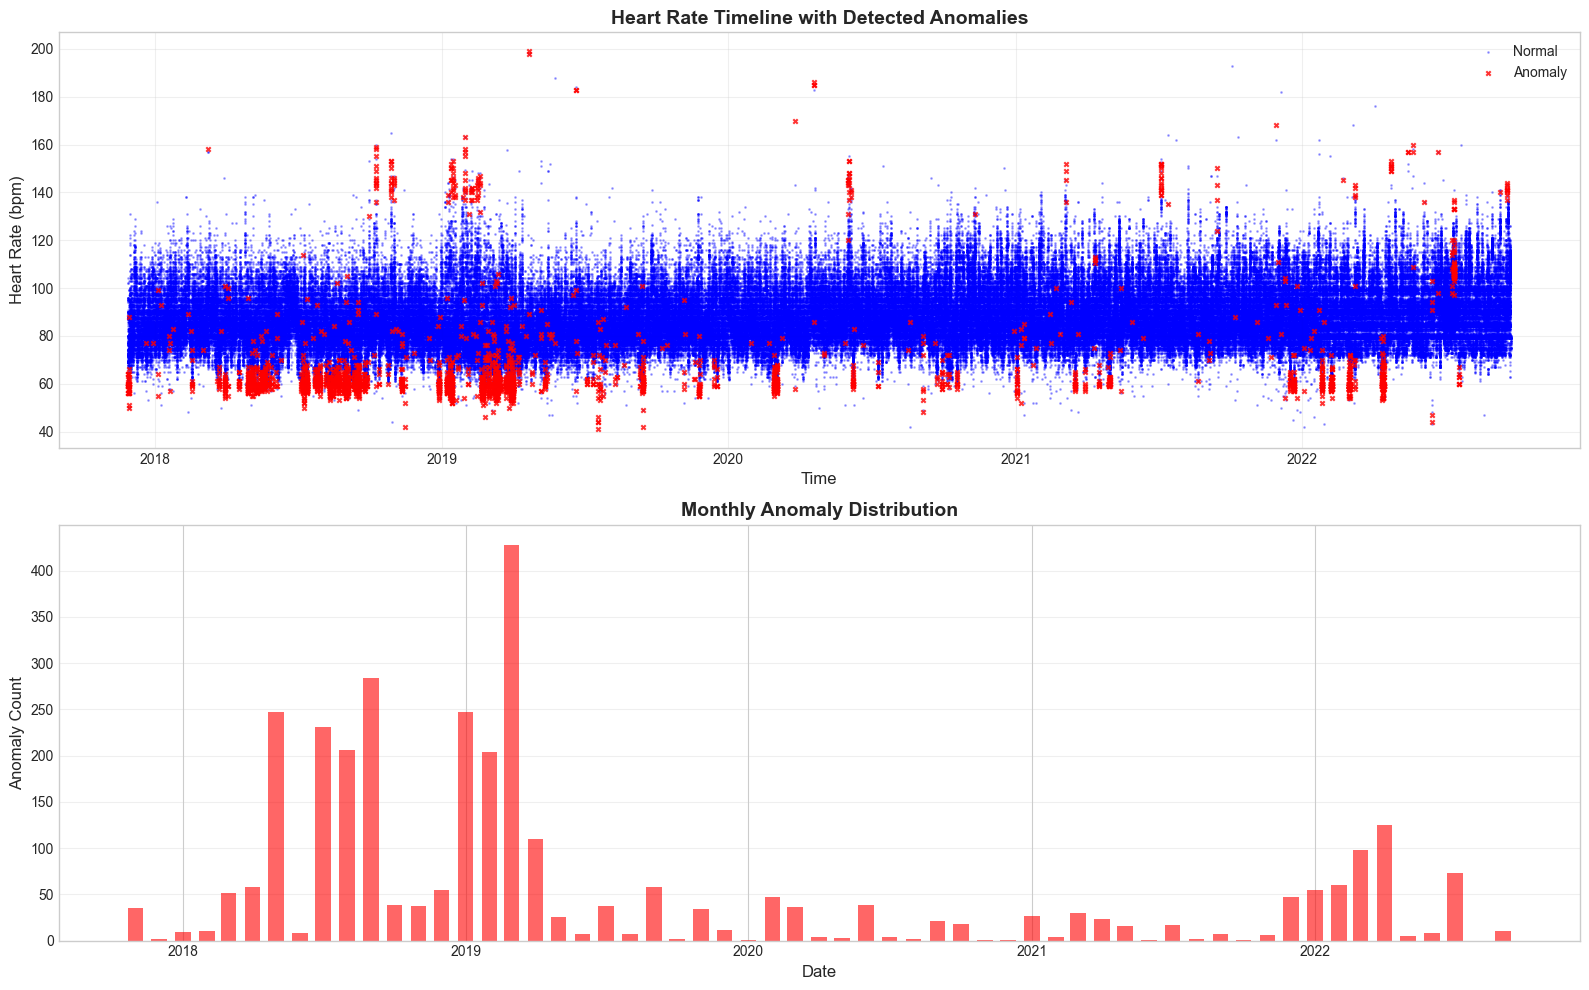

In [36]:
# Phase 4.3: Create anomaly timeline visualization
print("⏳ Creating anomaly timeline visualization...")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: HR values over time with anomalies highlighted
ax1 = axes[0]

# Plot all HR values
predictions_df_sorted = predictions_df.sort_values('timestamp')
normal_data = predictions_df_sorted[predictions_df_sorted['predicted_anomaly'] == 0]
anomaly_data = predictions_df_sorted[predictions_df_sorted['predicted_anomaly'] == 1]

ax1.scatter(normal_data['timestamp'], normal_data['hr_value'], 
           c='blue', alpha=0.3, s=1, label='Normal')
ax1.scatter(anomaly_data['timestamp'], anomaly_data['hr_value'], 
           c='red', alpha=0.8, s=10, label='Anomaly', marker='x')

ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Heart Rate (bpm)', fontsize=12)
ax1.set_title('Heart Rate Timeline with Detected Anomalies', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Anomaly count over time (monthly aggregation)
ax2 = axes[1]

anomalies_df_sorted = anomalies_df.sort_values('timestamp')
anomalies_df_sorted['year_month'] = pd.to_datetime(anomalies_df_sorted['timestamp']).dt.to_period('M')
monthly_anomalies = anomalies_df_sorted.groupby('year_month').size()

# Convert period to timestamp for plotting
monthly_anomalies.index = monthly_anomalies.index.to_timestamp()

ax2.bar(monthly_anomalies.index, monthly_anomalies.values, width=20, color='red', alpha=0.6)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Anomaly Count', fontsize=12)
ax2.set_title('Monthly Anomaly Distribution', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save figure
timeline_path = os.path.join(OUTPUT_DIR, 'anomaly_timeline.png')
plt.savefig(timeline_path, dpi=150, bbox_inches='tight')
print(f"✅ Timeline visualization saved to: {timeline_path}")

plt.show()

⏳ Creating context distribution visualizations...
✅ Context distribution visualization saved to: C:\Project\Apple Health Data\output\context_distribution.png


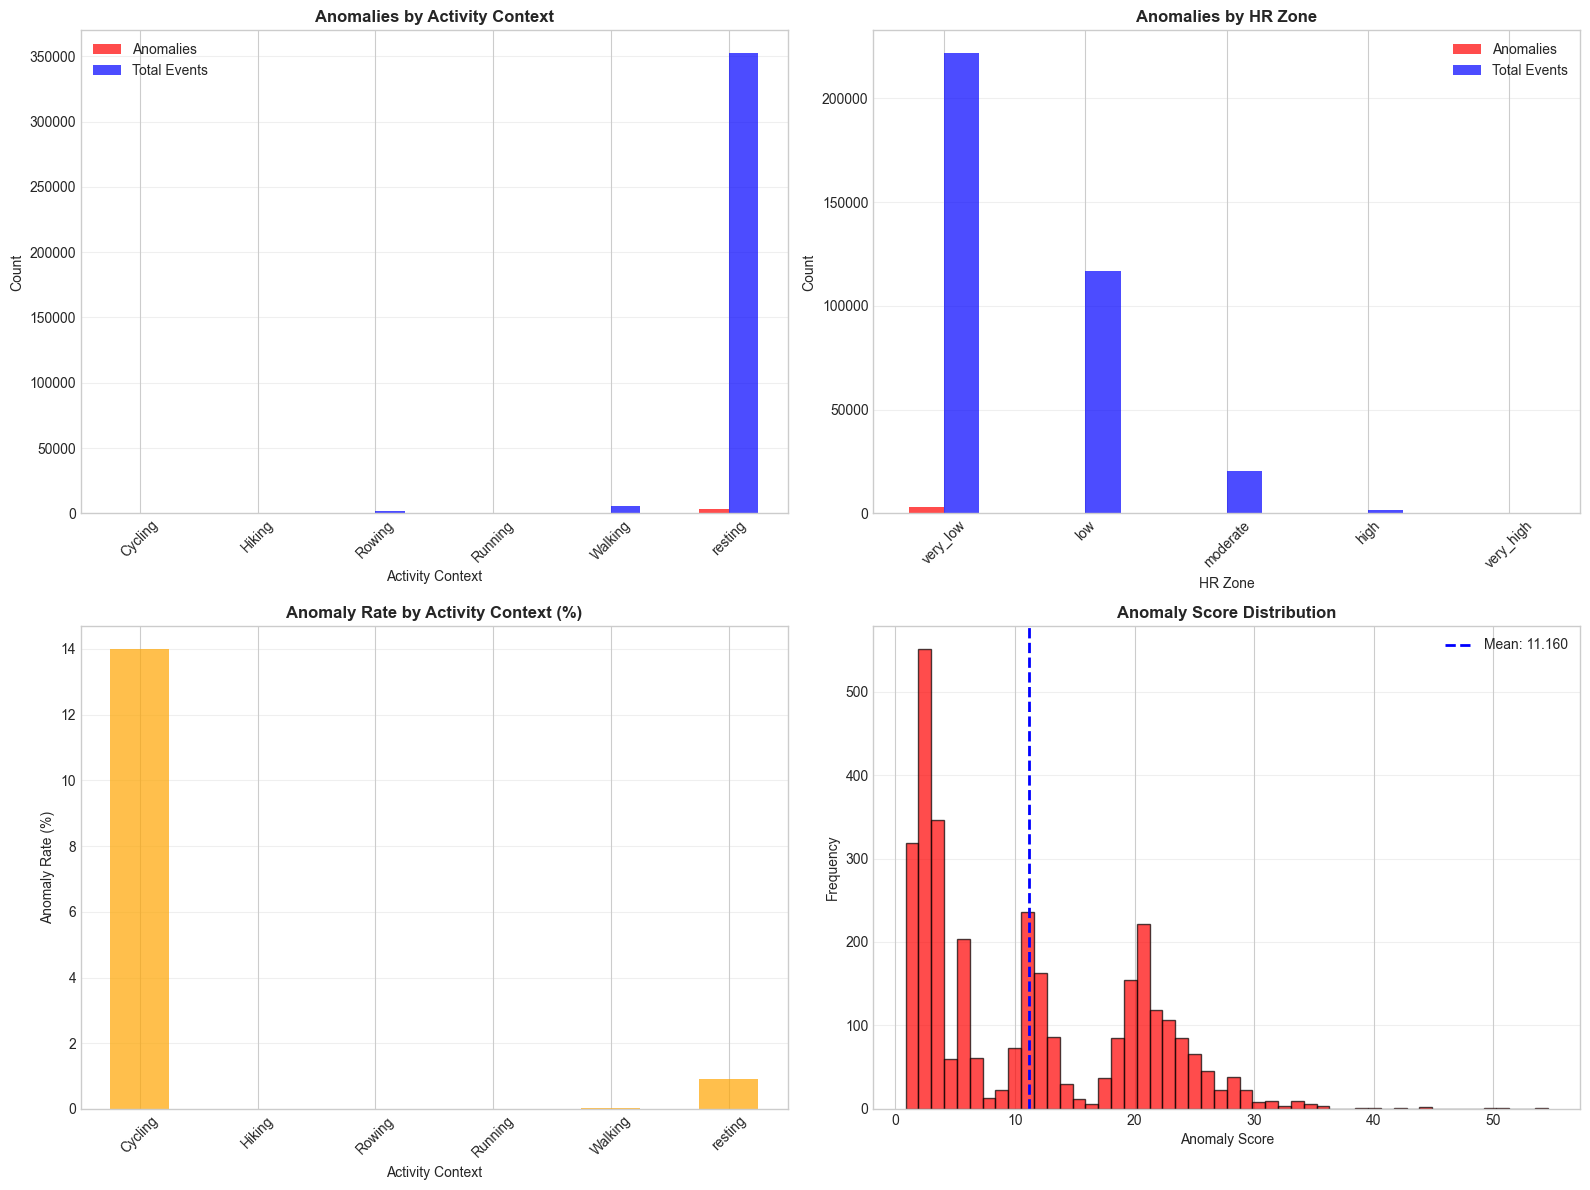

In [37]:
# Phase 4.4: Create context distribution visualizations
print("⏳ Creating context distribution visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Anomalies by Activity Context
ax1 = axes[0, 0]
activity_data = predictions_df.groupby('activity_context')['predicted_anomaly'].agg(['sum', 'count'])
activity_data.plot(kind='bar', ax=ax1, color=['red', 'blue'], alpha=0.7)
ax1.set_title('Anomalies by Activity Context', fontsize=12, fontweight='bold')
ax1.set_xlabel('Activity Context')
ax1.set_ylabel('Count')
ax1.legend(['Anomalies', 'Total Events'])
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Anomalies by HR Zone
ax2 = axes[0, 1]
hr_zone_data = predictions_df.groupby('hr_zone')['predicted_anomaly'].agg(['sum', 'count'])
# Order by HR zone intensity
zone_order = ['very_low', 'low', 'moderate', 'high', 'very_high']
hr_zone_data = hr_zone_data.reindex([z for z in zone_order if z in hr_zone_data.index])
hr_zone_data.plot(kind='bar', ax=ax2, color=['red', 'blue'], alpha=0.7)
ax2.set_title('Anomalies by HR Zone', fontsize=12, fontweight='bold')
ax2.set_xlabel('HR Zone')
ax2.set_ylabel('Count')
ax2.legend(['Anomalies', 'Total Events'])
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Anomaly Rate by Activity Context (percentage)
ax3 = axes[1, 0]
activity_anomaly_rate = (predictions_df.groupby('activity_context')['predicted_anomaly'].sum() / 
                         predictions_df.groupby('activity_context')['predicted_anomaly'].count() * 100)
activity_anomaly_rate.plot(kind='bar', ax=ax3, color='orange', alpha=0.7)
ax3.set_title('Anomaly Rate by Activity Context (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Activity Context')
ax3.set_ylabel('Anomaly Rate (%)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Anomaly Score Distribution
ax4 = axes[1, 1]
ax4.hist(anomaly_data['anomaly_score'], bins=50, color='red', alpha=0.7, edgecolor='black')
ax4.axvline(anomaly_data['anomaly_score'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Mean: {anomaly_data["anomaly_score"].mean():.3f}')
ax4.set_title('Anomaly Score Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Anomaly Score')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save figure
distribution_path = os.path.join(OUTPUT_DIR, 'context_distribution.png')
plt.savefig(distribution_path, dpi=150, bbox_inches='tight')
print(f"✅ Context distribution visualization saved to: {distribution_path}")

plt.show()

In [38]:
# Phase 4.5: Export final predictions for external validation
print("⏳ Exporting final predictions CSV for external validation...")

# Create comprehensive predictions DataFrame
final_predictions = predictions_df.copy()

# Add additional context columns from original hr_df by merging on timestamp
# First, create a mapping from event_id to hr_df index
event_id_to_hr_idx = {}
for idx in event_indices:
    node_id = idx_to_node[idx]
    # Extract the index from event_id (e.g., "event_123" -> 123)
    hr_idx = int(node_id.split('_')[1])
    event_id_to_hr_idx[node_id] = hr_idx

# Add more context columns
final_predictions['event_id_numeric'] = final_predictions['event_id'].apply(
    lambda x: int(x.split('_')[1]) if isinstance(x, str) else x
)

# Merge with hr_df to get additional context
hr_context = hr_df[['time_period', 'hour', 'day_of_week', 'is_weekend', 'type']].copy()
hr_context['event_id_numeric'] = hr_context.index

final_predictions = final_predictions.merge(
    hr_context, 
    on='event_id_numeric', 
    how='left', 
    suffixes=('', '_hr')
)

# Select and order columns for final output
final_columns = [
    'timestamp', 
    'hr_value', 
    'predicted_anomaly', 
    'anomaly_score',
    'activity_context',
    'hr_zone',
    'time_period',
    'hour',
    'day_of_week',
    'is_weekend',
    'type'
]

final_export = final_predictions[final_columns].copy()

# Export to CSV
final_predictions_path = os.path.join(OUTPUT_DIR, 'anomaly_predictions.csv')
final_export.to_csv(final_predictions_path, index=False)

print(f"✅ Final predictions exported to: {final_predictions_path}")
print(f"   Total records: {len(final_export):,}")
print(f"   Columns: {len(final_export.columns)}")
print(f"\n   Preview:")
print(final_export.head(10))

⏳ Exporting final predictions CSV for external validation...
✅ Final predictions exported to: C:\Project\Apple Health Data\output\anomaly_predictions.csv
   Total records: 360,178
   Columns: 11

   Preview:
            timestamp  hr_value  predicted_anomaly  anomaly_score  \
0 2017-11-27 09:47:34      82.0                  0       0.110758   
1 2017-11-27 10:00:39      72.0                  0       0.075281   
2 2017-11-27 10:01:51      74.0                  0       0.190959   
3 2017-11-27 10:08:29      74.0                  0       0.294281   
4 2017-11-27 10:11:17      74.0                  0       0.274435   
5 2017-11-27 10:20:53      76.0                  0       0.255928   
6 2017-11-27 10:24:35      74.0                  0       0.238669   
7 2017-11-27 10:28:43      77.0                  0       0.230480   
8 2017-11-27 10:28:46      77.0                  0       0.200442   
9 2017-11-27 10:28:53      78.0                  0       0.174476   

  activity_context   hr_zone tim

In [39]:
# Phase 4.6: Export top anomalies
print("⏳ Exporting top 100 anomalies...")

# Export top anomalies
top_anomalies_export = final_export[final_export['predicted_anomaly'] == 1].nlargest(
    100, 'anomaly_score'
)

top_anomalies_path = os.path.join(OUTPUT_DIR, 'top_anomalies.csv')
top_anomalies_export.to_csv(top_anomalies_path, index=False)

print(f"✅ Top 100 anomalies exported to: {top_anomalies_path}")
print(f"\n   Top 5 Anomalies:")
print(top_anomalies_export[['timestamp', 'hr_value', 'anomaly_score', 'activity_context', 'hr_zone']].head())

⏳ Exporting top 100 anomalies...
✅ Top 100 anomalies exported to: C:\Project\Apple Health Data\output\top_anomalies.csv

   Top 5 Anomalies:
                 timestamp  hr_value  anomaly_score activity_context   hr_zone
127215 2019-09-14 16:46:00      42.0      54.548420          resting  very_low
116807 2019-07-18 22:29:02      44.0      50.388168          resting  very_low
116810 2019-07-18 22:44:15      44.0      50.218800          resting  very_low
66307  2018-11-15 21:35:54      59.0      44.604187          resting  very_low
116808 2019-07-18 22:33:33      57.0      44.604187          resting  very_low


In [40]:
# Phase 4.7: Generate summary report

print("⏳ Generating summary statistics report...")

# Create summary text report
summary_report = []
summary_report.append("=" * 80)
summary_report.append("COPE + GNN ANOMALY DETECTION SUMMARY REPORT")
summary_report.append("=" * 80)
summary_report.append(f"\nGenerated: {pd.Timestamp.now()}")
summary_report.append(f"\n{'='*80}")

# Data overview
summary_report.append("\n1. DATA OVERVIEW")
summary_report.append("-" * 80)
summary_report.append(f"Total HR records analyzed: {len(final_export):,}")
summary_report.append(f"Date range: {final_export['timestamp'].min()} to {final_export['timestamp'].max()}")
summary_report.append(f"Total workouts: {len(workouts_df):,}")

# Anomaly detection results
summary_report.append(f"\n2. ANOMALY DETECTION RESULTS")
summary_report.append("-" * 80)
total_anomalies = final_export['predicted_anomaly'].sum()
total_normal = (final_export['predicted_anomaly'] == 0).sum()
summary_report.append(f"Total anomalies detected: {total_anomalies:,} ({total_anomalies/len(final_export)*100:.2f}%)")
summary_report.append(f"Total normal events: {total_normal:,} ({total_normal/len(final_export)*100:.2f}%)")
summary_report.append(f"Average anomaly score: {final_export[final_export['predicted_anomaly']==1]['anomaly_score'].mean():.4f}")

# Distribution analysis
summary_report.append(f"\n3. ANOMALY DISTRIBUTION BY CONTEXT")
summary_report.append("-" * 80)

# By activity
summary_report.append("\nBy Activity Context:")
activity_summary = final_export.groupby('activity_context')['predicted_anomaly'].agg(['sum', 'count'])
for activity, row in activity_summary.iterrows():
    pct = (row['sum'] / row['count'] * 100) if row['count'] > 0 else 0
    summary_report.append(f"  {activity:15s}: {int(row['sum']):5,} / {int(row['count']):6,} ({pct:5.2f}%)")

# By HR zone
summary_report.append("\nBy HR Zone:")
hr_zone_summary = final_export.groupby('hr_zone')['predicted_anomaly'].agg(['sum', 'count'])
zone_order = ['very_low', 'low', 'moderate', 'high', 'very_high']
for zone in zone_order:
    if zone in hr_zone_summary.index:
        row = hr_zone_summary.loc[zone]
        pct = (row['sum'] / row['count'] * 100) if row['count'] > 0 else 0
        summary_report.append(f"  {zone:15s}: {int(row['sum']):5,} / {int(row['count']):6,} ({pct:5.2f}%)")

# By time period
summary_report.append("\nBy Time Period:")
time_summary = final_export.groupby('time_period')['predicted_anomaly'].agg(['sum', 'count'])
for period, row in time_summary.iterrows():
    pct = (row['sum'] / row['count'] * 100) if row['count'] > 0 else 0
    summary_report.append(f"  {period:15s}: {int(row['sum']):5,} / {int(row['count']):6,} ({pct:5.2f}%)")

# Output files
summary_report.append(f"\n4. OUTPUT FILES")
summary_report.append("-" * 80)
summary_report.append(f"COPE Graph:           {os.path.basename(graph_file_path)}")
summary_report.append(f"GNN Model:            {os.path.basename(model_path)}")
summary_report.append(f"All Predictions:      {os.path.basename(final_predictions_path)}")
summary_report.append(f"Top 100 Anomalies:    {os.path.basename(top_anomalies_path)}")
summary_report.append(f"Timeline Plot:        anomaly_timeline.png")
summary_report.append(f"Distribution Plot:    context_distribution.png")

summary_report.append(f"\n{'='*80}")
summary_report.append("END OF REPORT")
summary_report.append("=" * 80)

# Save report
summary_text = "\n".join(summary_report)
summary_path = os.path.join(OUTPUT_DIR, 'anomaly_summary.txt')

with open(summary_path, 'w') as f:
    f.write(summary_text)

print(f"✅ Summary report saved to: {summary_path}")
print(f"\n{summary_text}")

⏳ Generating summary statistics report...
✅ Summary report saved to: C:\Project\Apple Health Data\output\anomaly_summary.txt

COPE + GNN ANOMALY DETECTION SUMMARY REPORT

Generated: 2026-02-05 22:55:56.325338


1. DATA OVERVIEW
--------------------------------------------------------------------------------
Total HR records analyzed: 360,178
Date range: 2017-11-27 09:47:34 to 2022-09-23 10:59:44
Total workouts: 278

2. ANOMALY DETECTION RESULTS
--------------------------------------------------------------------------------
Total anomalies detected: 3,234 (0.90%)
Total normal events: 356,944 (99.10%)
Average anomaly score: 11.1599

3. ANOMALY DISTRIBUTION BY CONTEXT
--------------------------------------------------------------------------------

By Activity Context:
  Cycling        :    70 /    500 (14.00%)
  Hiking         :     0 /     17 ( 0.00%)
  Rowing         :     0 /  1,710 ( 0.00%)
  Running        :     0 /      1 ( 0.00%)
  Walking        :     1 /  5,792 ( 0.02%)
  resti

In [41]:
# Phase 4 Checkpoint: Verify all outputs generated
print("=" * 80)
print("✅ PHASE 4 CHECKPOINT: Anomaly Detection & Validation Complete")
print("=" * 80)

# List of expected output files
expected_files = {
    'COPE Graph': graph_file_path,
    'GNN Model': model_path,
    'All Predictions CSV': final_predictions_path,
    'Top 100 Anomalies CSV': top_anomalies_path,
    'Summary Report': summary_path,
    'Timeline Visualization': timeline_path,
    'Distribution Visualization': distribution_path
}

print(f"\n✓ Output Files Verification:")
all_files_ok = True

for name, filepath in expected_files.items():
    if os.path.exists(filepath):
        file_size = os.path.getsize(filepath)
        if file_size > 1024 * 1024:
            size_str = f"{file_size / (1024*1024):.2f} MB"
        else:
            size_str = f"{file_size / 1024:.2f} KB"
        print(f"   ✓ {name:30s}: {size_str:>12s}")
    else:
        print(f"   ✗ {name:30s}: MISSING")
        all_files_ok = False

# Verify predictions CSV has correct structure
print(f"\n✓ Data Validation:")
print(f"   ✓ Predictions records: {len(final_export):,}")
print(f"   ✓ Predictions columns: {len(final_export.columns)}")
print(f"   ✓ Anomalies detected: {final_export['predicted_anomaly'].sum():,}")

# Check if ready for external validation
print(f"\n✓ External Validation Readiness:")
if 'timestamp' in final_export.columns and 'predicted_anomaly' in final_export.columns:
    print(f"   ✓ anomaly_predictions.csv ready for ground truth comparison")
    print(f"   ✓ Contains timestamps and anomaly predictions")
    print(f"   ✓ Contains context information (activity, HR zone, time period)")
else:
    print(f"   ✗ Missing required columns for validation")

# Summary
print(f"\n{'='*80}")
print(f"🎉 ALL 4 PHASES COMPLETE!")
print(f"{'='*80}")

print(f"\n📊 Pipeline Summary:")
print(f"   Phase 1: Context Enrichment ✓")
print(f"   Phase 2: COPE Graph Construction ✓")
print(f"   Phase 3: GNN Model Training ✓")
print(f"   Phase 4: Anomaly Detection & Validation ✓")

print(f"\n📁 All output files saved to: {OUTPUT_DIR}")

print(f"\n{'='*80}")

✅ PHASE 4 CHECKPOINT: Anomaly Detection & Validation Complete

✓ Output Files Verification:
   ✓ COPE Graph                    :    110.54 MB
   ✓ GNN Model                     :     20.61 KB
   ✓ All Predictions CSV           :     31.73 MB
   ✓ Top 100 Anomalies CSV         :      8.93 KB
   ✓ Summary Report                :      2.11 KB
   ✓ Timeline Visualization        :    550.21 KB
   ✓ Distribution Visualization    :    165.20 KB

✓ Data Validation:
   ✓ Predictions records: 360,178
   ✓ Predictions columns: 11
   ✓ Anomalies detected: 3,234

✓ External Validation Readiness:
   ✓ anomaly_predictions.csv ready for ground truth comparison
   ✓ Contains timestamps and anomaly predictions
   ✓ Contains context information (activity, HR zone, time period)

🎉 ALL 4 PHASES COMPLETE!

📊 Pipeline Summary:
   Phase 1: Context Enrichment ✓
   Phase 2: COPE Graph Construction ✓
   Phase 3: GNN Model Training ✓
   Phase 4: Anomaly Detection & Validation ✓

📁 All output files saved to: C:\Pr